# 2. Предобработка, признаки, обучение

От сырых EDF до сдаваемой модели (`model/weights/model.json`, протокол 8): конвейер, признаки и их смысл, валидация без утечки, обучение, сравнение с поведением и без, история протоколов 1–8.

Сдаваемая модель — только ЭЭГ покоя. Инференс и метрики — ноутбук 3, конфаундеры — ноутбук 4.

In [1]:
import json
import sys
import tempfile
import warnings
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "results" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from model.model import load, save, train
from src import config, dataset, evaluation, features, final_model, models, preprocessing, task_branch, viz

warnings.filterwarnings("ignore", message="The least populated class")
warnings.filterwarnings("ignore", message="Mean of empty slice")
viz.apply_style()
pd.set_option("display.precision", 3)
VALIDATION = ROOT / "results" / "validation"
P8 = models.PROTOCOL_8

## 2.1 Конвейер

| Шаг | Что делается | Зачем |
| --- | --- | --- |
| Чтение | 6 каналов по имени, отсчёты → мкВ | порядок каналов в файлах разный |
| Края | обрезка нулевого хвоста формата B | ступенька «сигнал → 0» связана с меткой |
| Частота | ресэмплинг к 125 Гц | в данных 123–127 Гц |
| ФНЧ | 40 Гц | выше 40 Гц спектр зависит от формата |
| Окна | 4 с с шагом 2 с | разрешение 0.25 Гц, запись не склеивается |
| Отбраковка | плоский сигнал, насыщение, размах > 400 мкВ, выброс дисперсии, выпадение, копия канала | общие пороги для всех; ICA без EOG на 6 каналах ненадёжна |
| Спектр | среднее log-периодограмм + γ/ln 10 | смещение не зависит от числа годных окон |
| Признаки | доли мощности, альфа-пик, наклон, асимметрия | не зависят от общего усиления |
| Модель | импутация → стандартизация → логистическая регрессия L2 → калибровка Платта | 25 ПТСР: нужна простая и объяснимая модель |

Отдельная нормализация сигнала не нужна: признаки относительные, а стандартизация — внутри модели. Перереференция не делается: средний референт по шести отведениям ненадёжен.

## 2.2 Отбраковка на отдельных записях

По горизонтали — начало окна, по вертикали — канал, цвет — причина отбраковки. Сверху — покой испытуемого с ПТСР, снизу — проба соматоформного испытуемого с артефактами на височных каналах.

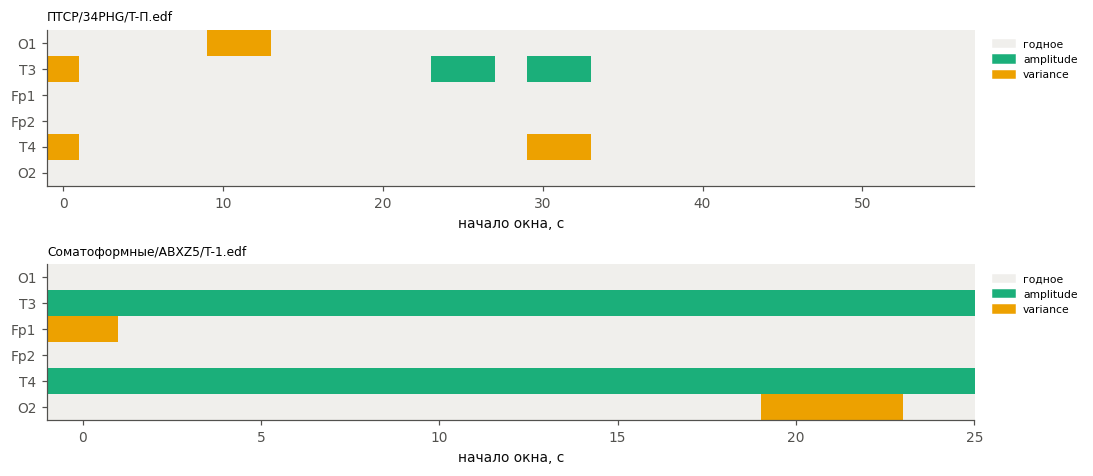

доля годных окон,O1,T3,Fp1,Fp2,T4,O2
ПТСР/34PHG/T-П.edf,0.931,0.828,1.000,1.0,0.897,1.000
Соматоформные/ABXZ5/T-1.edf,1.000,0.000,0.923,1.0,0.000,0.846


In [2]:
examples = ["ПТСР/34PHG/T-П.edf", "Соматоформные/ABXZ5/T-1.edf"]
cfg = preprocessing.PreprocessingConfig()
fig, axes = plt.subplots(len(examples), 1, figsize=(10, 4.4))
rows = []
for ax, relpath in zip(axes, examples):
    epoched = preprocessing.preprocess_file(config.DATA_DIR / relpath, cfg)
    viz.plot_rejection(ax, epoched.reject, cfg.step_s)
    ax.set_title(relpath, loc="left", fontsize=8)
    rows.append(pd.Series(epoched.good.mean(axis=0), index=config.CHANNELS, name=relpath))
plt.tight_layout()
plt.show()
pd.DataFrame(rows).rename_axis(columns="доля годных окон")

Качество записи связано с когортой (годных окон в покое: норма 98%, ПТСР 87%, соматоформные 75%), поэтому в модель оно не подаётся; модель только на качестве — ноутбук 4.

## 2.3 Спектр и признаки одного испытуемого

Покой, O1, норма формата A: фон 1/f (прямая в log–log на 3–30 Гц без 7–14 Гц, наклон χ — `rest_exponent`), альфа-пик над фоном (`rest_iaf_O1`, `rest_alpha_peak_O1`) и полосы мощности. Поправка +γ/ln 10 делает оценку логарифма мощности несмещённой при любом числе окон.

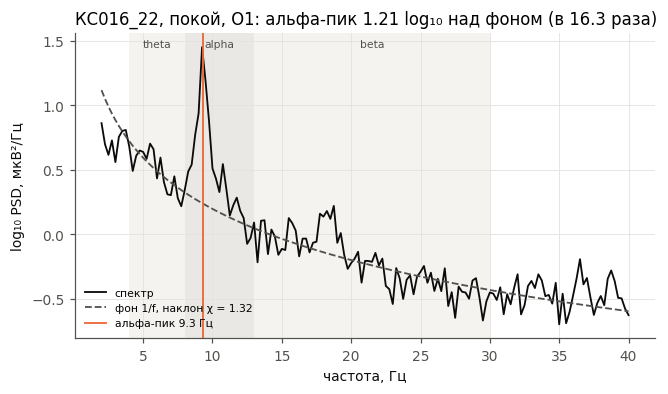

,rest_relpow_theta_O1,rest_relpow_theta_Fp1,rest_relpow_theta_Fp2,rest_relpow_theta_T3,rest_relpow_theta_T4,rest_relpow_alpha_O1,rest_relpow_alpha_Fp1,rest_relpow_alpha_Fp2,rest_relpow_alpha_T3,rest_relpow_alpha_T4,...,rest_relpow_beta_T3,rest_relpow_beta_T4,rest_iaf_O1,rest_alpha_peak_O1,rest_exponent_O1,rest_exponent_Fp1,rest_exponent_Fp2,rest_exponent_T3,rest_exponent_T4,rest_faa
КС016_22,-0.566,-0.689,-0.637,-0.446,-0.63,-0.306,-0.174,-0.203,-0.506,-0.298,...,-0.482,-0.582,9.304,1.211,1.319,1.371,1.386,1.201,1.117,0.1


In [3]:
example = config.DATA_DIR / "Норма/КС016_22"
files = dataset.find_record_files(example)
epoched = preprocessing.preprocess_file(files[config.REST_STEM], cfg)
freqs, spectrum = features.record_spectrum(epoched)
log_o1 = np.log10(spectrum[config.CHANNELS.index("O1")])
chi, offset = features.background_fit(freqs, log_o1)
iaf, peak = features.alpha_peak(freqs, log_o1)
fig, ax = plt.subplots(figsize=(6.8, 3.6))
viz.plot_spectrum_features(ax, freqs, log_o1, chi, offset, iaf)
ax.set_title(f"{example.name}, покой, O1: альфа-пик {peak:.2f} log₁₀ над фоном (в {10 ** peak:.1f} раза)", loc="left")
plt.show()

subject = features.extract_subject_features(files)
model_features = P8.feature_sets["rest_O1FpT_exp"][1]
pd.Series({name: subject[name] for name in model_features}, name=example.name).to_frame().T

## 2.4 Признаки сдаваемой модели

23 признака покоя с закрытыми глазами:

| Признак | Отведения | Смысл |
| --- | --- | --- |
| доли мощности тета 4–8, альфа 8–13, бета 13–30 Гц (15) | O1, Fp1, Fp2, T3, T4 | баланс ритмов покоя; при ПТСР описаны ослабление альфы и рост быстрых ритмов (Kovacevic et al., 2025) |
| частота альфа-пика | O1 | скорость альфа-ритма; снижается со старением |
| высота альфа-пика | O1 | выраженность эффекта Бергера |
| наклон спектра (5) | O1, Fp1, Fp2, T3, T4 | апериодический фон (Donoghue et al., 2020); уплощается при ПТСР и со старением |
| лобная асимметрия альфа | Fp1, Fp2 | модель приближения/избегания; Fp чувствительны к глазам |

O2 не используется: в дополнительной партии он ведёт себя как лобный канал. T3/T4 оставлены, их влияние проверяется в ноутбуке 4. Связность и микросостояния не используются (ноутбук 1, раздел 1.10).

In [4]:
data = models.load_training_data(protocol=P8)
x = pd.DataFrame(data.tables["rest_O1FpT_exp"], index=list(data.subject_keys), columns=data.feature_names["rest_O1FpT_exp"])
print(f"Испытуемых: {len(data.subject_keys)}, независимых групп: {np.unique(data.groups).size}, признаков: {x.shape[1]}")
missing = x.isna().groupby(data.stratum).mean()
pd.DataFrame({
    "испытуемых": pd.Series(data.stratum).value_counts(),
    "пропуски O1/Fp": missing[[c for c in x.columns if c.endswith(("_O1", "_Fp1", "_Fp2"))]].mean(axis=1),
    "пропуски T3/T4": missing[[c for c in x.columns if c.endswith(("_T3", "_T4"))]].mean(axis=1),
    "нет альфа-пика (IAF)": missing["rest_iaf_O1"],
    "пропуски FAA": missing["rest_faa"],
}).reindex(list(viz.STRATUM_ORDER)).rename(index=viz.STRATUM_LABELS)

Испытуемых: 229, независимых групп: 221, признаков: 23


,испытуемых,пропуски O1/Fp,пропуски T3/T4,нет альфа-пика (IAF),пропуски FAA
ПТСР,25,0.020,0.020,0.080,0.000
норма A,20,0.014,0.000,0.200,0.000
норма B,2,0.000,0.000,0.000,0.000
норма C,45,0.071,0.000,1.000,0.000
доп. нормы,40,0.009,0.212,0.125,0.000
нормы 65+,23,0.056,0.087,0.783,0.000
соматоформные,74,0.054,0.216,0.203,0.027


Пропуск — меньше 5 годных окон на канале; частота альфа-пика пропускается и тогда, когда пика нет. Пропуски заполняются медианой обучения.

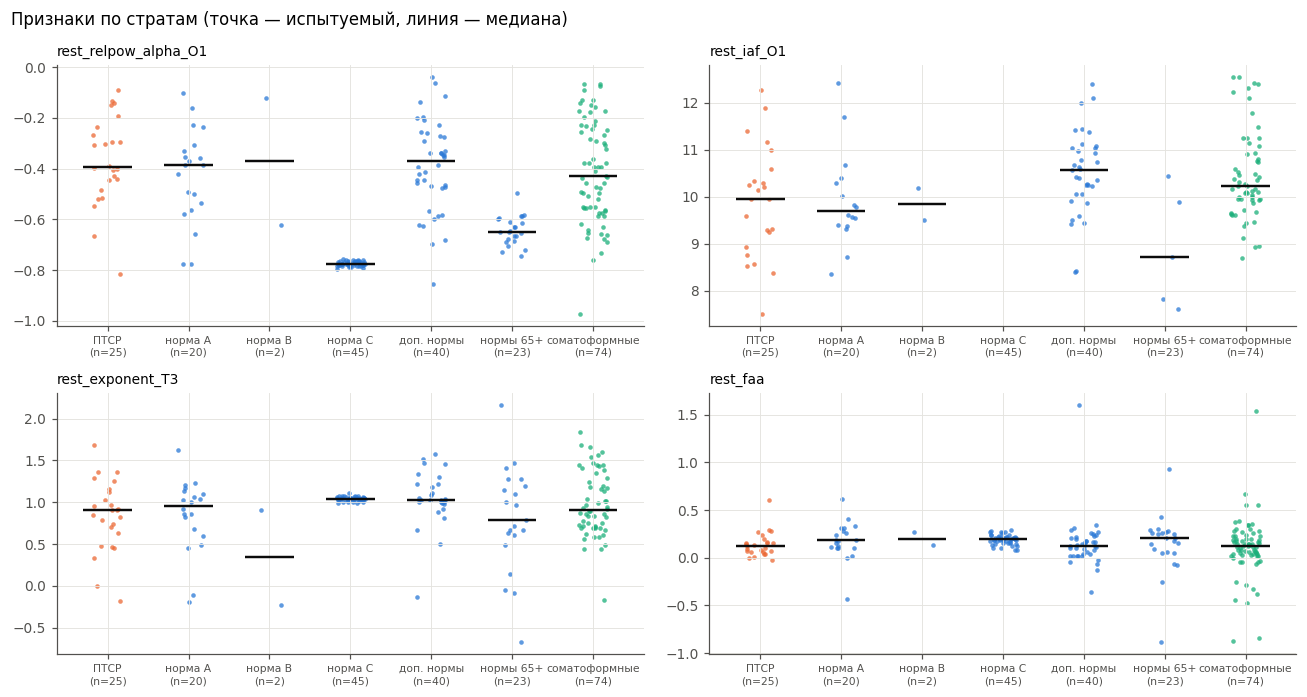

In [5]:
show = ["rest_relpow_alpha_O1", "rest_iaf_O1", "rest_exponent_T3", "rest_faa"]
fig, axes = plt.subplots(2, 2, figsize=(12, 6.4))
for ax, name in zip(axes.ravel(), show):
    viz.plot_by_stratum(ax, x[name].to_numpy(), data.stratum)
    ax.set_title(name, loc="left", fontsize=9)
fig.suptitle("Признаки по стратам (точка — испытуемый, линия — медиана)", x=0.01, ha="left")
plt.tight_layout()
plt.show()

## 2.5 Валидация без утечки

- Единица разбиения — группа дубликатов: ID с общими записями всегда вместе.
- Внешний цикл — leave-one-group-out (строже leave-one-subject-out из ТЗ).
- Внутренний цикл — групповая 5-fold CV: в ней выбираются признаки, C, отрицательный класс и калибровка.
- Импутация, стандартизация, веса и калибровка обучаются только на train; окна между train и test не делятся.

In [6]:
folds = evaluation.outer_folds(data.groups)
keys = np.array(data.subject_keys)
assert all(np.intersect1d(data.groups[tr], data.groups[te]).size == 0 for tr, te in folds)
assert all(np.intersect1d(keys[tr], keys[te]).size == 0 for tr, te in folds)
multi = pd.Series(keys).groupby(data.groups).agg(list)
print(f"Внешних фолдов: {len(folds)}; испытуемых: {keys.size}; пересечений групп train/test: 0")
print("Группы из нескольких ID (общие записи):")
multi[multi.str.len() > 1].to_frame("ID в группе")

Внешних фолдов: 221; испытуемых: 229; пересечений групп train/test: 0
Группы из нескольких ID (общие записи):


,ID в группе
132,"[ПТСР/DFGH, ПТСР/WSXD]"
163,"[Соматоформные/DIKL0, Соматоформные/GHRD3]"
179,"[Соматоформные/KRTM8, Соматоформные/PYVB0]"
181,"[Соматоформные/LDPR3, Соматоформные/ZILO6]"
187,"[Соматоформные/MVCP4, Соматоформные/ORSU8]"
193,"[Соматоформные/QJHD2, Соматоформные/YLKT9]"
200,"[Соматоформные/RZFM9, Соматоформные/VGYN1]"
202,"[Соматоформные/SIGO3, Соматоформные/TMVN4]"


## 2.6 Кандидаты и критерий выбора

80 кандидатов: 4 набора признаков × 5 значений C × 2 варианта отрицательного класса × вес норм 65+ и соматоформных (1 или 3). Критерий повторяет объективную оценку ТЗ без порога:

`30·max(0, (AUC_нормы − 0.5)/0.5) + 20·max(0, (AUC_специфичность − 0.5)/0.5)`,

где AUC_нормы — ПТСР против норм моложе 65, AUC_специфичность — против норм 65+ и соматоформных. Калибровка Платта с равными весами классов, затем порог сдвигается в точку равных ошибок: чувствительность на ПТСР = специфичность на нормах 65+ и соматоформных (по внутренним OOF-предсказаниям).

In [7]:
sets = {key: len(names) for key, (_, names) in P8.feature_sets.items()}
print("Наборы признаков (число признаков):", sets)
print("Кандидатов:", len(P8.candidates))

Наборы признаков (число признаков): {'rest_O1Fp': 12, 'rest_O1Fp_exp': 15, 'rest_O1FpT': 18, 'rest_O1FpT_exp': 23}
Кандидатов: 80


## 2.7 Вложенная оценка (протокол 8)

В каждом из 221 внешнего фолда повторяется вся процедура: выбор, обучение, калибровка. Результат сверяется с сохранённым прогоном.

In [8]:
oof = evaluation.nested_oof(data, P8)
committed = pd.read_csv(VALIDATION / "protocol8" / "nested_oof.csv", index_col=0).loc[oof.index]
print(f"Максимальное расхождение с сохранённым прогоном: {np.abs(oof['p'] - committed['p']).max():.1e}")
print("Выбранные кандидаты по внешним фолдам:", evaluation.candidate_frequency(oof))
per_fold = oof.groupby("split_group")[["cal_a", "cal_b"]].first()
print(f"Калибровка Платта по фолдам: a — медиана {per_fold['cal_a'].median():.2f} "
      f"[{per_fold['cal_a'].min():.2f}; {per_fold['cal_a'].max():.2f}], b — медиана {per_fold['cal_b'].median():.2f}")
report = evaluation.summarize_protocol3(oof, data.groups)
pd.DataFrame({
    col: {
        "AUC ПТСР / нормы < 65": report[col]["auc_ptsd_vs_controls_excl_ageing"]["value"],
        "AUC ПТСР / нормы A, B, доп.": report[col]["auc_ptsd_vs_controls_AB"]["value"],
        "AUC ПТСР / нормы 65+": report[col]["auc_ptsd_vs_stratum"]["control_ageing"],
        "AUC ПТСР / соматоформные": report[col]["auc_ptsd_vs_stratum"]["somatoform"],
        "чувствительность при 0.5": report[col]["threshold_metrics"]["sensitivity_ptsd"],
        "специфичность 65+": report[col]["specificity_ageing"]["value"],
        "специфичность соматоформных": report[col]["specificity_somatoform"]["value"],
    }
    for col in ("p_raw", "p")
}).rename(columns={"p_raw": "некалиброванная", "p": "калиброванная (сдаётся)"})

Максимальное расхождение с сохранённым прогоном: 1.1e-16
Выбранные кандидаты по внешним фолдам: {'C=1.0|neg=control+somatoform|feat=rest_O1FpT_exp': 136, 'C=1.0|neg=control+somatoform|feat=rest_O1FpT_exp|w=3': 55, 'C=1.0|neg=control|feat=rest_O1FpT_exp|w=3': 12, 'C=0.3|neg=control+somatoform|feat=rest_O1FpT_exp|w=3': 10, 'C=1.0|neg=control|feat=rest_O1FpT_exp': 8}
Калибровка Платта по фолдам: a — медиана 0.69 [0.31; 0.88], b — медиана 0.27


,некалиброванная,калиброванная (сдаётся)
AUC ПТСР / нормы < 65,0.864,0.824
"AUC ПТСР / нормы A, B, доп.",0.765,0.697
AUC ПТСР / нормы 65+,0.890,0.877
AUC ПТСР / соматоформные,0.792,0.731
чувствительность при 0.5,0.800,0.840
специфичность 65+,0.870,0.870
специфичность соматоформных,0.662,0.608


Калиброванный OOF-AUC ниже, потому что калибровка различается между фолдами; у финальной модели калибровка одна и не меняет ранжирование. Метрики с ДИ — ноутбук 3.

## 2.8 Финальная модель

Та же процедура на всех 229 испытуемых; веса — простые массивы в JSON, без pickle. Переобучение воспроизводит веса до округления.

In [9]:
fitted = train()
committed_model = load(ROOT / "model" / "weights")
with tempfile.TemporaryDirectory() as tmp:
    save(fitted, Path(tmp))
    fitted_json = load(Path(tmp))
assert fitted_json.feature_names == committed_model.feature_names
max_param = max(np.max(np.abs(np.append(getattr(fitted_json, name), 0) - np.append(getattr(committed_model, name), 0)))
                for name in ("impute_values", "mean", "scale", "coef", "intercept", "calibration"))
x_all = data.tables[fitted.metadata["feature_set"]]
max_p = np.max(np.abs(fitted_json.predict_proba(x_all) - committed_model.predict_proba(x_all)))
print(f"Переобучение против model/weights/model.json: max |Δ параметра| = {max_param:.1e}, max |Δ P| = {max_p:.1e}")
meta = fitted.metadata
print(f"Выбран: {meta['candidate']}; обучено на {meta['n_subjects_trained']} испытуемых ({meta['n_ptsd']} ПТСР); "
      f"калибровка Платта a = {fitted.calibration[0]:.3f}, b = {fitted.calibration[1]:.3f}")
top = pd.Series(meta["selection_scores"]).sort_values(ascending=False).head(5)
top.rename("критерий внутренней CV (из 50)").to_frame()

Переобучение против model/weights/model.json: max |Δ параметра| = 0.0e+00, max |Δ P| = 0.0e+00
Выбран: C=1.0|neg=control+somatoform|feat=rest_O1FpT_exp; обучено на 229 испытуемых (25 ПТСР); калибровка Платта a = 0.822, b = 0.236


,критерий внутренней CV (из 50)
C=1.0|neg=control+somatoform|feat=rest_O1FpT_exp,30.858
C=0.3|neg=control+somatoform|feat=rest_O1FpT_exp|w=3,30.209
C=1.0|neg=control+somatoform|feat=rest_O1FpT_exp|w=3,30.103
C=0.3|neg=control+somatoform|feat=rest_O1FpT_exp,30.031
C=1.0|neg=control|feat=rest_O1FpT_exp,28.657


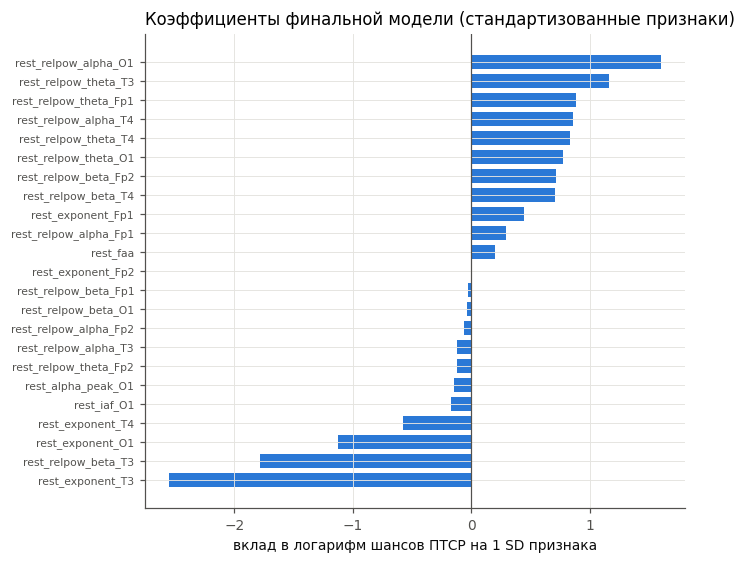

In [10]:
coef = pd.Series(fitted.coef, index=fitted.feature_names).sort_values()
fig, ax = plt.subplots(figsize=(6.4, 5.2))
ax.barh(coef.index, coef.to_numpy(), color=viz.COHORT_COLORS[config.GROUP_CONTROL], height=0.7)
ax.axvline(0, color=viz.TEXT_MUTED, lw=0.8)
ax.set_xlabel("вклад в логарифм шансов ПТСР на 1 SD признака")
ax.set_title("Коэффициенты финальной модели (стандартизованные признаки)", loc="left")
ax.tick_params(axis="y", labelsize=7)
plt.tight_layout()
plt.show()

Положительный коэффициент — большее значение признака повышает P. Признаки коррелированы, поэтому коэффициенты читаются как направление, а не как независимые эффекты; интерпретация — ноутбук 4, раздел 4.7.

## 2.9 С поведением и без

Поведение — время решения первой таблицы Шульте. Оно есть не у всех (у формата C длительности шаблонные, у дополнительной партии проб нет), поэтому сравнение — на 142 испытуемых: ПТСР, нормы A и B, 65+, соматоформные. Три модели на одних людях и разбиениях: поведение, ЭЭГ (признаки сдаваемой модели), вместе.

In [11]:
table, subjects_t, stratum_t, family_t = final_model.build_tables()
population = final_model.training_population(table, subjects_t, stratum_t, family_t)
eeg_features = fitted.feature_names
specs = {"behaviour": final_model.BEHAVIOUR, "rest_eeg": eeg_features, "combined": final_model.BEHAVIOUR + eeg_features}
beh_oofs = {name: task_branch.nested_oof_task(population, feats, score=final_model.criterion) for name, feats in specs.items()}
beh_report = final_model.summarize(population, beh_oofs)
print("Испытуемых по стратам:", beh_report["n_by_stratum"])


def row(entry: dict) -> dict:
    e = entry["p_raw"]
    return {
        "AUC ПТСР / нормы A, B": e["auc_ptsd_vs_controls_AB"]["value"],
        "AUC ПТСР / 65+ и соматоформные": e["auc_ptsd_vs_ageing_and_somatoform"]["value"],
        "AUC ПТСР / все не-ПТСР": e["auc_ptsd_vs_all_non_ptsd"]["value"],
        "95% ДИ (все не-ПТСР)": f"[{e['auc_ptsd_vs_all_non_ptsd']['ci_low']:.2f}; {e['auc_ptsd_vs_all_non_ptsd']['ci_high']:.2f}]",
        "AUC ПТСР / нормы 65+": e["auc_ptsd_vs_stratum"]["control_ageing"],
        "AUC ПТСР / соматоформные": e["auc_ptsd_vs_stratum"]["somatoform"],
    }


names = {"behaviour": "только поведение", "rest_eeg": "только ЭЭГ", "combined": "ЭЭГ + поведение"}
pd.DataFrame({names[k]: row(beh_report[k]) for k in names}).T

Испытуемых по стратам: {np.str_('control_A'): 20, np.str_('control_B'): 2, np.str_('control_ageing'): 23, np.str_('ptsd'): 25, np.str_('somatoform'): 72}


,"AUC ПТСР / нормы A, B",AUC ПТСР / 65+ и соматоформные,AUC ПТСР / все не-ПТСР,95% ДИ (все не-ПТСР),AUC ПТСР / нормы 65+,AUC ПТСР / соматоформные
только поведение,0.722,0.587,0.612,[0.50; 0.73],0.082,0.748
только ЭЭГ,0.498,0.677,0.644,[0.54; 0.74],0.833,0.628
ЭЭГ + поведение,0.66,0.768,0.747,[0.65; 0.84],0.746,0.774


In [12]:
diffs = {
    "ЭЭГ + поведение − только поведение": beh_report["combined_minus_behaviour_auc_all"],
    "ЭЭГ + поведение − только ЭЭГ": beh_report["combined_minus_rest_eeg_auc_all"],
}
pd.DataFrame(diffs).T.rename(columns={"value": "разность AUC (все не-ПТСР)", "ci_low": "2.5%", "ci_high": "97.5%"})

,разность AUC (все не-ПТСР),2.5%,97.5%
ЭЭГ + поведение − только поведение,0.135,0.004,0.260
ЭЭГ + поведение − только ЭЭГ,0.104,0.034,0.176


Заранее зафиксированные сравнения протоколов 4–5 (AUC ПТСР против всех не-ПТСР):

In [13]:
p4 = json.loads((VALIDATION / "protocol4" / "metrics.json").read_text(encoding="utf-8"))
p5 = json.loads((VALIDATION / "protocol5" / "metrics.json").read_text(encoding="utf-8"))
kinds = [("поведение", "behaviour"), ("ЭЭГ", "eeg"), ("вместе", "combined")]
prereg = {
    f"протокол 4: первая проба, ЭЭГ задачи ({sum(p4['trial1']['n_by_stratum'].values())})":
        {m: p4["trial1"][k]["p_raw"]["auc_ptsd_vs_all_non_ptsd"]["value"] for m, k in kinds},
    f"протокол 4: динамика пяти проб ({sum(p4['dynamics']['n_by_stratum'].values())})":
        {m: p4["dynamics"][k]["p_raw"]["auc_ptsd_vs_all_non_ptsd"]["value"] for m, k in kinds},
    f"протокол 5: первая проба + ЭЭГ покоя 4–20 Гц ({sum(p5['n_by_stratum'].values())})":
        {m: p5[k]["p_raw"]["auc_ptsd_vs_all_non_ptsd"]["value"] for m, k in [("поведение", "behaviour"), ("ЭЭГ", "rest_eeg"), ("вместе", "combined")]},
}
pd.DataFrame(prereg).T

,поведение,ЭЭГ,вместе
"протокол 4: первая проба, ЭЭГ задачи (142)",0.613,0.562,0.625
протокол 4: динамика пяти проб (115),0.759,0.531,0.729
протокол 5: первая проба + ЭЭГ покоя 4–20 Гц (142),0.612,0.573,0.656


- **Поведение** отделяет ПТСР от молодых норм (0.72), но пожилых принимает за ПТСР (0.08): они решают медленнее.
- **ЭЭГ** отделяет пожилых (0.83), но в этой популяции не различает ПТСР и нормы A/B (0.50).
- **Вместе** — 0.75 [0.65; 0.84], прирост значим относительно каждой модели: сигналы дополняют друг друга.

Сдаётся модель только на ЭЭГ: задача хакатона — ЭЭГ-диагностика, а поведения нет у 85 из 229 испытуемых обучения.

## 2.10 История: протоколы 1–8

Все протоколы зафиксированы до запуска и показаны, включая неудачные. Состав данных менялся, поэтому AUC между строками сравниваются осторожно.

In [14]:
def load_metrics(name: str) -> dict:
    return json.loads((VALIDATION / name / "metrics.json").read_text(encoding="utf-8"))


m1, m2 = load_metrics("protocol1_corrected"), load_metrics("protocol2")
history = {
    "1: покой + задача, 39 признаков, все каналы": {
        "испытуемых": m1["n_subjects"], "AUC ПТСР / нормы": m1["auc_ptsd_vs_control"]["value"],
        "чувствительность": m1["sensitivity"], "специфичность соматоформных": m1["specificity_somatoform"]["value"],
        "специфичность 65+": np.nan},
    "2: покой, без O2, ± T3/T4, наклон, доп. партия": {
        "испытуемых": sum(m2["n_by_stratum"].values()), "AUC ПТСР / нормы": m2["auc_ptsd_vs_all_controls"]["value"],
        "чувствительность": m2["sensitivity_ptsd"], "специфичность соматоформных": m2["specificity_somatoform"]["value"],
        "специфичность 65+": np.nan},
}
for name, label in [("protocol3", "3: покой 4–20 Гц, O1/Fp, калибровка по составу"),
                    ("protocol6", "6: как 2 + нормы 65+ в обучении, критерий ТЗ"),
                    ("protocol7", "7: как 6 + FAA, сбалансированная калибровка"),
                    ("protocol8", "8: как 7 + вес групп специфичности, порог равных ошибок (сдаётся)")]:
    m = load_metrics(name)
    history[label] = {
        "испытуемых": sum(m["n_by_stratum"].values()), "AUC ПТСР / нормы": m["p_raw"]["auc_ptsd_vs_controls_excl_ageing"]["value"],
        "чувствительность": m["p"]["threshold_metrics"]["sensitivity_ptsd"],
        "специфичность соматоформных": m["p"]["specificity_somatoform"]["value"],
        "специфичность 65+": m["p"]["specificity_ageing"]["value"]}
pd.DataFrame(history).T

,испытуемых,AUC ПТСР / нормы,чувствительность,специфичность соматоформных,специфичность 65+
"1: покой + задача, 39 признаков, все каналы",166.0,0.818,0.64,0.662,NaN
"2: покой, без O2, ± T3/T4, наклон, доп. партия",206.0,0.824,0.68,0.676,NaN
"3: покой 4–20 Гц, O1/Fp, калибровка по составу",229.0,0.659,0.00,1.000,1.000
"6: как 2 + нормы 65+ в обучении, критерий ТЗ",229.0,0.848,0.00,0.986,1.000
"7: как 6 + FAA, сбалансированная калибровка",229.0,0.838,0.80,0.581,0.783
"8: как 7 + вес групп специфичности, порог равных ошибок (сдаётся)",229.0,0.864,0.84,0.608,0.870


- **1–2:** высокий AUC почти целиком за счёт формата C и различий партий через T3.
- **3:** в «устойчивых» признаках (O1/Fp, 4–20 Гц) различения с сопоставимыми нормами нет (0.50); калибровка по составу обучения даёт чувствительность 0.
- **4–5:** сигнал найден в поведении (раздел 2.9).
- **6–7:** модель только на ЭЭГ, критерий — формула ТЗ, сбалансированная калибровка.
- **8 (сдаётся):** вес групп специфичности и порог в точке равных ошибок — выше и AUC, и специфичность.

## 2.11 Выводы

1. Предобработка одинакова для обучения и инференса и не использует метку.
2. 23 признака покоя на пяти отведениях, не зависящие от общего усиления.
3. Валидация — leave-one-group-out по группам дубликатов, весь выбор внутри фолдов; набор признаков один и тот же во всех 221 фолде.
4. OOF: AUC ПТСР против норм моложе 65 — 0.864, против норм A/B и доп. партии — 0.765, против 65+ — 0.89, против соматоформных — 0.79; при 0.5 чувствительность 0.84.
5. Поведение и ЭЭГ дополняют друг друга (0.75 вместе); сдаётся модель только на ЭЭГ.
6. Главный риск — опора на T3/T4 и различия партий; проверки — ноутбук 4.